In [1]:
import os
import sys
sys.path.append('..')
import time
from mdx.analytics.core.schema.config import AppConfig
from mdx.analytics.core.utils.io_utils import ValidateFile, validate_file_path, load_json_from_file
from mdx.analytics.core.utils.crs import CoordinateReferenceSystem as crs
from mdx.analytics.core.schema.models import Coordinate, GeoLocation, Point, Location

In [2]:
config_path = '../resources/smart_city_config.json'
valid_config_path = validate_file_path(config_path)
if not os.path.exists(valid_config_path):
    logging.error(
        f"ERROR: The indicated config file `{valid_config_path}` does NOT exist.")
    exit(1)

config = AppConfig(**load_json_from_file(valid_config_path))

# config.coordinateReferenceSystem.roadNetwork.graph.osmLoadMethod = "from_place"
# config.coordinateReferenceSystem.roadNetwork.graph.osmLoadMethod = "from_point"
# config.coordinateReferenceSystem.roadNetwork.graph.osmLoadMethod = "from_file"
# config.coordinateReferenceSystem.roadNetwork.graph.osmSimplify = True
# config.coordinateReferenceSystem.roadNetwork.roadNetworkUseCRSCartesian = True
# config.coordinateReferenceSystem.crsCartesian = "EPSG:3395"
# config.coordinateReferenceSystem.roadNetwork.visualization.visualizationGraphShowGraph = True
# config.coordinateReferenceSystem.inputDataInCRSCartesian = True
config.coordinateReferenceSystem.roadNetwork.visualization.visualizationMapZoomPath = True


crs_config = config.coordinateReferenceSystem
crs_mdx = crs(crs_config)

In [ ]:
# line_segment_path = '../tests/resources/line_segment_v0.3.json'
# network_path_03 = '../tests/resources/network_v0.3.json'
# network_path_30 = '../tests/resources/network_v3.0.json'


# # create network JSON file from line_segment
# crs_mdx.create_network_json_file(line_segment_path, network_path_30)
# networkITS.write_network_json_to_kml(network_path_30,'data/network_path_30_1007.kml')
# networkITS.write_network_json_to_kml(network_path_03,'data/network_path_03.kml')

In [3]:
test_traj_lonlat = [
        [
          -90.66492345852421,
          42.48626781250441
        ],
        [
          -90.66493460080686,
          42.486276275887995
        ],
        [
          -90.66494755621915,
          42.486304919246585
        ]
      ]

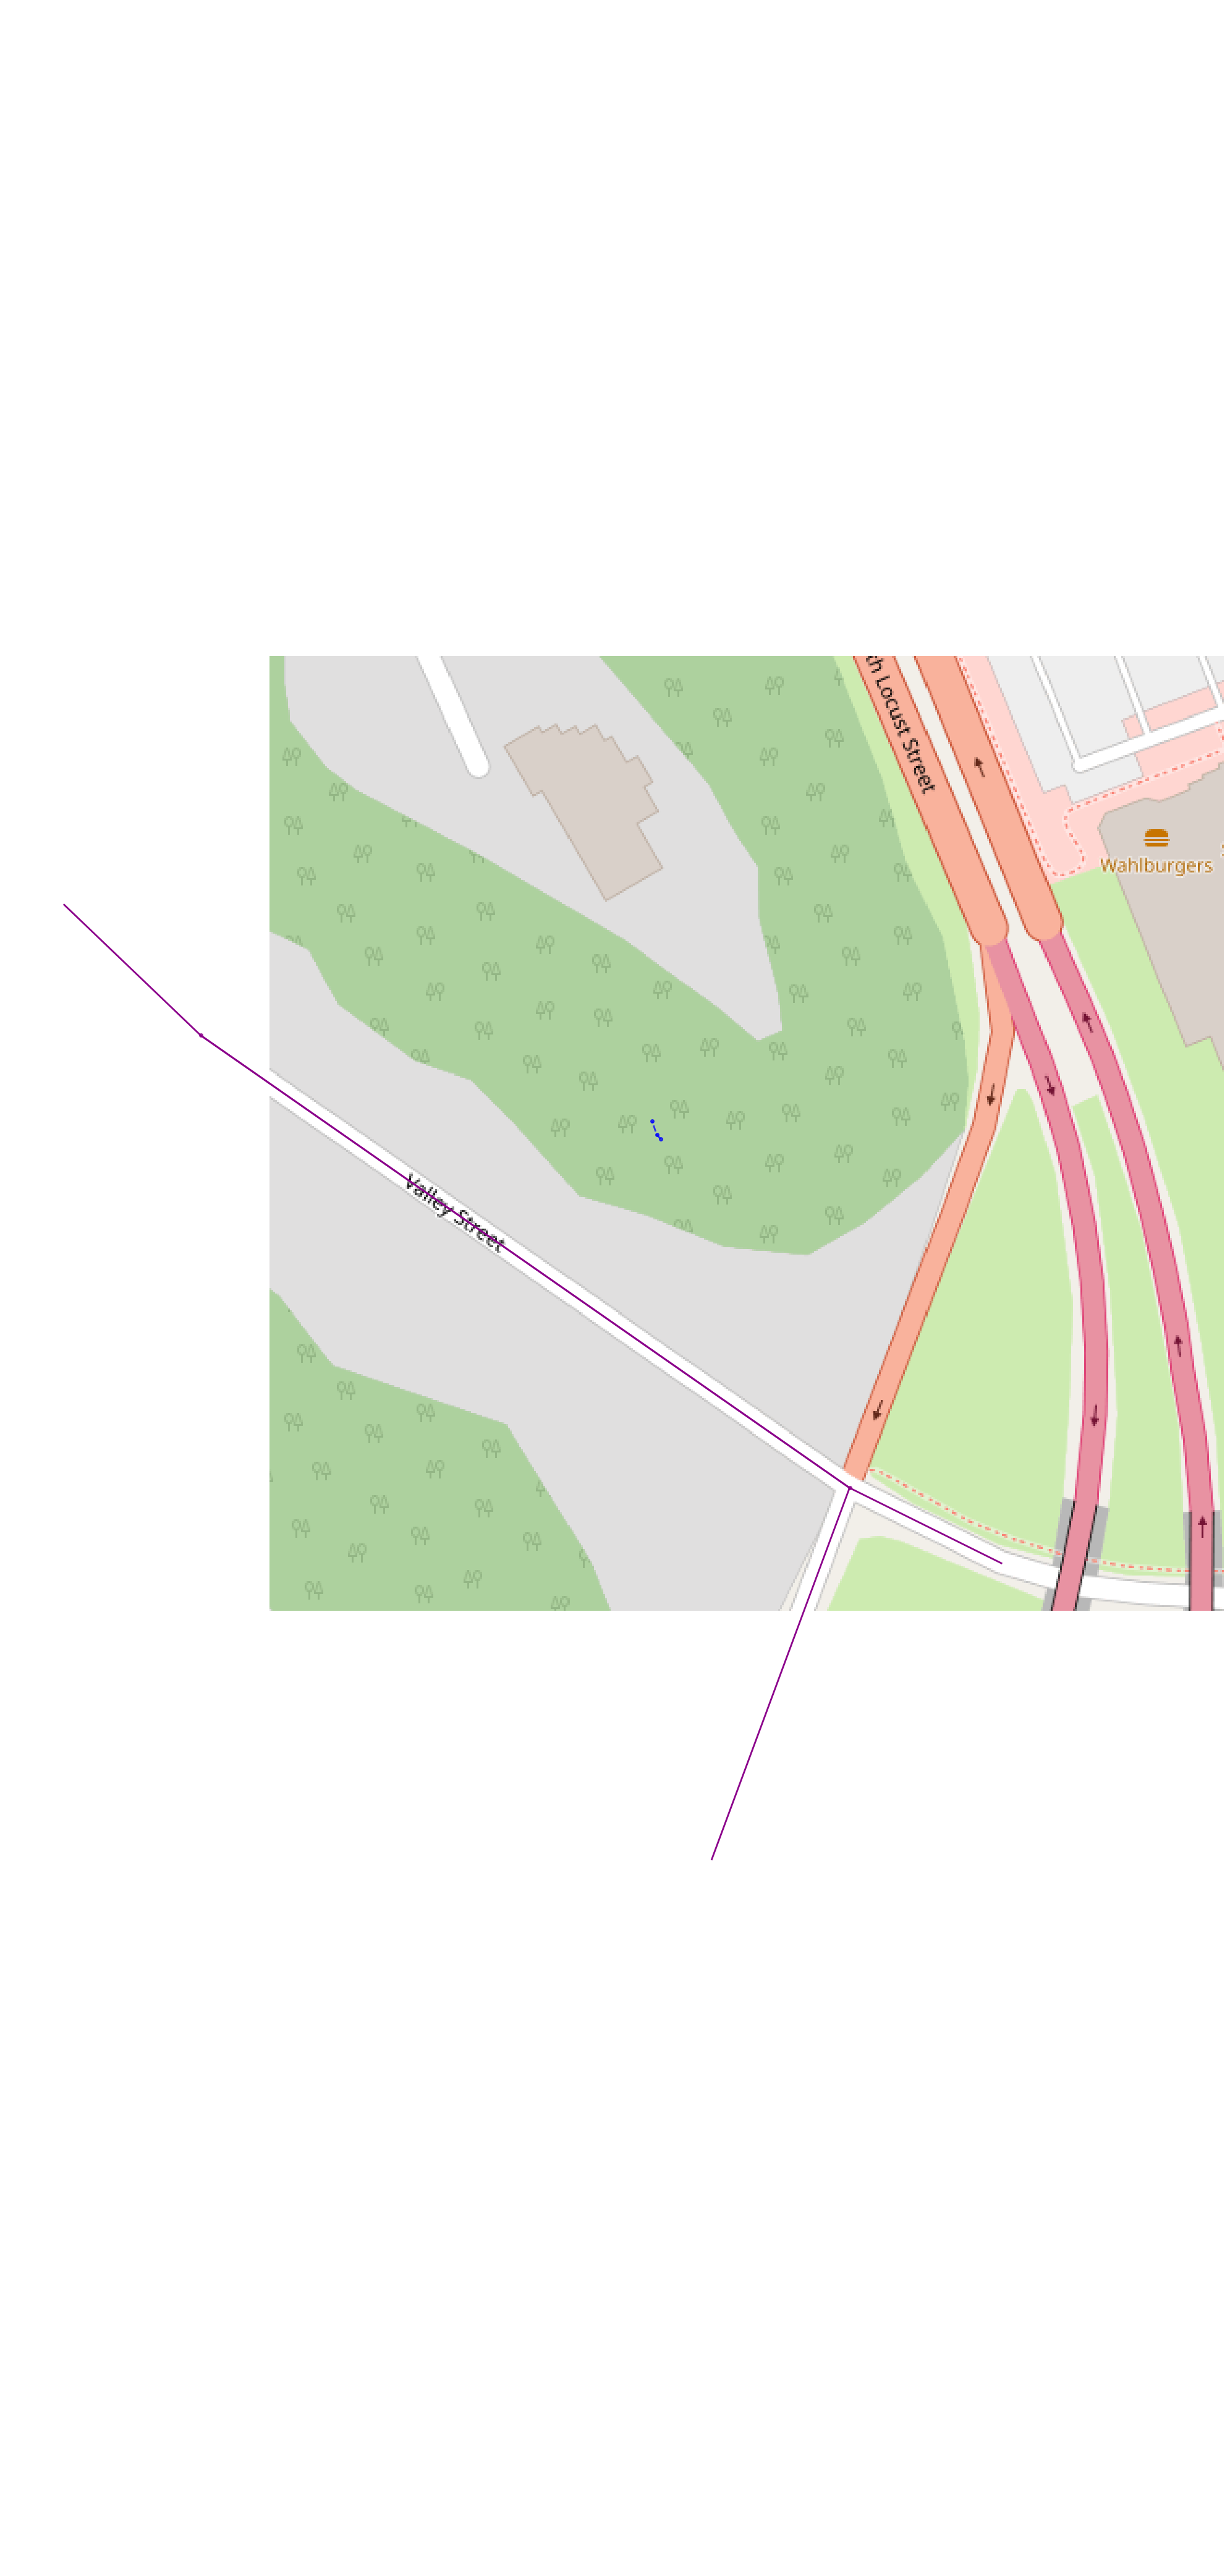

In [6]:
route_latlon = [(lat,lon) for lon,lat in test_traj_lonlat]
route_latlon_map_matched = crs_mdx.map_matching(route_latlon)

# test2
crs_mdx.road_network.draw_map('test2.png')

In [10]:
for lon,lat in test_traj_lonlat:
    print(lat,',',lon)

42.467075873763314 , -90.45818166935857
42.474161820723914 , -90.52946689776006
42.46875836271174 , -90.47515191876658
42.46939020751177 , -90.48141905016794
42.46280962369264 , -90.41539091557976
42.465140918867505 , -90.43872526754643
42.467723912856705 , -90.46463275512475


Lowered zoom level to keep map size reasonable. (z = 13)


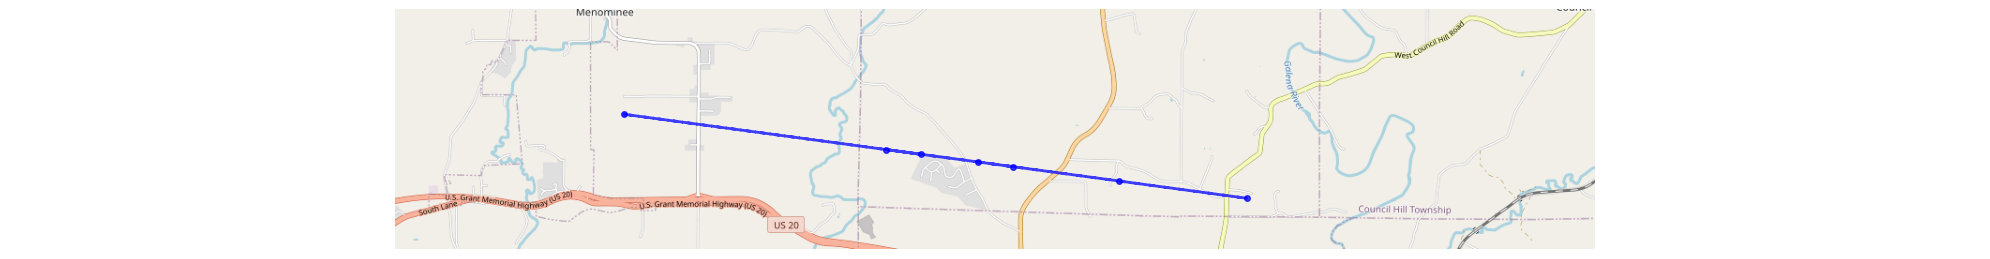

In [7]:

test_traj_lonlat =[
        [
          -90.45818166935857,
          42.467075873763314
        ],
        [
          -90.52946689776006,
          42.474161820723914
        ],
        [
          -90.47515191876658,
          42.46875836271174
        ],
        [
          -90.48141905016794,
          42.46939020751177
        ],
        [
          -90.41539091557976,
          42.46280962369264
        ],
        [
          -90.43872526754643,
          42.465140918867505
        ],
        [
          -90.46463275512475,
          42.467723912856705
        ]
      ]

route_latlon = [(lat,lon) for lon,lat in test_traj_lonlat]
route_latlon_map_matched = crs_mdx.map_matching(route_latlon)

# test2
crs_mdx.road_network.draw_map('test2.png')

In [ ]:
test_traj_pointsGeo = [Location(lat=42.49151878993689, lon=-90.70318181802834, alt=0.0), Location(lat=42.491517844962345, lon=-90.70317152337137, alt=0.0), Location(lat=42.491517127203174, lon=-90.70316209697553, alt=0.0), Location(lat=42.49151607815895, lon=-90.70314801249609, alt=0.0), Location(lat=42.49151501490573, lon=-90.70313348, alt=0.0), Location(lat=42.49151307072954, lon=-90.70310647901003, alt=0.0), Location(lat=42.491511267354625, lon=-90.70308036903808, alt=0.0), Location(lat=42.49150965367163, lon=-90.70305726883194, alt=0.0), Location(lat=42.49150859759594, lon=-90.70304226347142, alt=0.0), Location(lat=42.49150795784195, lon=-90.70303379727709, alt=0.0), Location(lat=42.491507543916974, lon=-90.70303108554025, alt=0.0), Location(lat=42.49150672932227, lon=-90.7030227793051, alt=0.0), Location(lat=42.49150543534803, lon=-90.7030074295562, alt=0.0), Location(lat=42.49150370625245, lon=-90.70298762061657, alt=0.0), Location(lat=42.491501479775515, lon=-90.70296053786038, alt=0.0), Location(lat=42.491498790057896, lon=-90.70292605589304, alt=0.0), Location(lat=42.491496158946134, lon=-90.70289412933563, alt=0.0), Location(lat=42.491493544748856, lon=-90.70286278596127, alt=0.0), Location(lat=42.49149091616833, lon=-90.70283050463034, alt=0.0), Location(lat=42.49148848962118, lon=-90.70280053864643, alt=0.0)]

In [ ]:
snapped_trajectory = crs_mdx.map_matching_location(test_traj_pointsGeo)
print(len(test_traj_pointsGeo))
print(len(snapped_trajectory))

In [ ]:
_, matched_lattice = crs_mdx.road_network.map_matching_for_edge(test_traj_pointsGeo)
print(matched_lattice)

In [ ]:
route_latlon = [(loc.lat,loc.lon) for loc in test_traj_pointsGeo]
route_latlon_map_matched = crs_mdx.map_matching(route_latlon)
crs_mdx.road_network.draw_map('data/mapmatching_test.png')
print('input traj length:',len(route_latlon))
print('mapmatched traj length:',len(route_latlon_map_matched))

In [ ]:
## perf test 
# test_traj_pointsGeo = [Location(lat=42.49151878993689, lon=-90.70318181802834, alt=0.0), Location(lat=42.491517844962345, lon=-90.70317152337137, alt=0.0), Location(lat=42.491517127203174, lon=-90.70316209697553, alt=0.0), Location(lat=42.49151607815895, lon=-90.70314801249609, alt=0.0), Location(lat=42.49151501490573, lon=-90.70313348, alt=0.0), Location(lat=42.49151307072954, lon=-90.70310647901003, alt=0.0), Location(lat=42.491511267354625, lon=-90.70308036903808, alt=0.0), Location(lat=42.49150965367163, lon=-90.70305726883194, alt=0.0), Location(lat=42.49150859759594, lon=-90.70304226347142, alt=0.0), Location(lat=42.49150795784195, lon=-90.70303379727709, alt=0.0), Location(lat=42.491507543916974, lon=-90.70303108554025, alt=0.0), Location(lat=42.49150672932227, lon=-90.7030227793051, alt=0.0), Location(lat=42.49150543534803, lon=-90.7030074295562, alt=0.0), Location(lat=42.49150370625245, lon=-90.70298762061657, alt=0.0), Location(lat=42.491501479775515, lon=-90.70296053786038, alt=0.0), Location(lat=42.491498790057896, lon=-90.70292605589304, alt=0.0), Location(lat=42.491496158946134, lon=-90.70289412933563, alt=0.0), Location(lat=42.491493544748856, lon=-90.70286278596127, alt=0.0), Location(lat=42.49149091616833, lon=-90.70283050463034, alt=0.0), Location(lat=42.49148848962118, lon=-90.70280053864643, alt=0.0)]
# route_latlon = [(loc.lat,loc.lon) for loc in test_traj_pointsGeo]
route_latlon = [(lat,lon) for lon,lat in test_traj_lonlat]
traj_length = 40
cnt = 500
num_detection = traj_length*cnt
route_latlon = route_latlon[:traj_length]
start = time.time()
for _ in range(cnt):
    route_latlon_map_matched = crs_mdx.map_matching(route_latlon)
end = time.time()
print('perf num detection per sec = ', round(num_detection/(end-start)))


In [ ]:
# test_traj_pointsGeo = [Location(lat=42.49151878993689, lon=-90.70318181802834, alt=0.0), Location(lat=42.491517844962345, lon=-90.70317152337137, alt=0.0), Location(lat=42.491517127203174, lon=-90.70316209697553, alt=0.0), Location(lat=42.49151607815895, lon=-90.70314801249609, alt=0.0), Location(lat=42.49151501490573, lon=-90.70313348, alt=0.0), Location(lat=42.49151307072954, lon=-90.70310647901003, alt=0.0), Location(lat=42.491511267354625, lon=-90.70308036903808, alt=0.0), Location(lat=42.49150965367163, lon=-90.70305726883194, alt=0.0), Location(lat=42.49150859759594, lon=-90.70304226347142, alt=0.0), Location(lat=42.49150795784195, lon=-90.70303379727709, alt=0.0), Location(lat=42.491507543916974, lon=-90.70303108554025, alt=0.0), Location(lat=42.49150672932227, lon=-90.7030227793051, alt=0.0), Location(lat=42.49150543534803, lon=-90.7030074295562, alt=0.0), Location(lat=42.49150370625245, lon=-90.70298762061657, alt=0.0), Location(lat=42.491501479775515, lon=-90.70296053786038, alt=0.0), Location(lat=42.491498790057896, lon=-90.70292605589304, alt=0.0), Location(lat=42.491496158946134, lon=-90.70289412933563, alt=0.0), Location(lat=42.491493544748856, lon=-90.70286278596127, alt=0.0), Location(lat=42.49149091616833, lon=-90.70283050463034, alt=0.0), Location(lat=42.49148848962118, lon=-90.70280053864643, alt=0.0)]
test_traj_pointsGeo = [Location(lat=pt[1],lon=pt[0]) for pt in test_traj_lonlat]
print(len(test_traj_pointsGeo))

traj_length = 20
cnt = 1000
num_detection = traj_length*cnt
test_traj_pointsGeo = test_traj_pointsGeo[:traj_length]
start = time.time()

# traj_latlon = [(loc.lat,loc.lon) for loc in test_traj_pointsGeo]

for _ in range(cnt):
    
    traj_latlon = [(loc.lat,loc.lon) for loc in test_traj_pointsGeo]
    snapped_trajectory = crs_mdx.map_matching_latlon(traj_latlon, 
                                                  exclude_non_emitting_state=False)
    snapped_trajectory = [Location(lat=pt[0],lon=pt[1]) for pt in snapped_trajectory]
    
end = time.time()
print('perf num detection per sec = ', round(num_detection/(end-start)))

In [ ]:
from mdx.analytics.core.schema.models import Location, Segment, Intersection, Network

def map_matching_location(pointsGeo, exclude_non_emitting_state=True):
        
    traj_latlon = [(loc.lat,loc.lon) for loc in pointsGeo]
    snapped_trajectory = crs_mdx.map_matching_latlon(traj_latlon, 
                                                  exclude_non_emitting_state=exclude_non_emitting_state)
    snapped_trajectory = [Location(lat=pt[0],lon=pt[1]) for pt in snapped_trajectory]

    return snapped_trajectory




In [ ]:
route_latlon = [(lat,lon) for lon,lat in test_traj_lonlat]
route_latlon_map_matched = crs_mdx.map_matching(route_latlon)
crs_mdx.road_network.draw_map('data/mapmatching_test.png')
print('input traj length:',len(route_latlon))
print('mapmatched traj length:',len(route_latlon_map_matched))


# list_of_trajectory_latlon = [self.route_latlon,route_latlon_map_matched]
# list_of_line_color = ['ffff0000', 'ff00ff00']
# self.crs_mdx.write_list_of_trajectory_latlon_to_kml(os.path.join(self.output_path,f'TestCRS_{self.suffix}_routes.kml'), list_of_trajectory_latlon, list_of_line_color=list_of_line_color)
      

In [ ]:
# 612

In [ ]:
# test1
crs_mdx.road_network.draw_graph('test.png')

In [ ]:
# test2
crs_mdx.road_network.draw_map('test2.png')

In [ ]:
# test3
# route_latlon = [(42.491437, -90.720450),(42.490914, -90.720450),(42.490815, -90.716531)]
route_latlon = [(42.491617, -90.720460),(42.491007, -90.720042),(42.491042, -90.718846),(42.490815, -90.716531)]
route_latlon_map_matched, distance_trajectory, distance_trajectory_map_matched = networkITS.map_matching(route_latlon)
print(len(route_latlon_map_matched))
print('distance_trajectory:',distance_trajectory)
print('distance_trajectory_map_matched:',distance_trajectory_map_matched)

In [ ]:
# test4
# route_latlon = [(42.491437, -90.720450),(42.490914, -90.720450),(42.490815, -90.716531)]
route_latlon = [(42.491617, -90.720460),(42.491007, -90.720042),(42.491042, -90.718846),(42.490815, -90.716531)]
route_xy = networkITS.trajectory_latlon_to_xy(route_latlon)
route_xy_map_matched, distance_trajectory, distance_trajectory_map_matched = networkITS.map_matching(route_xy)
print(len(route_xy_map_matched))
print('distance_trajectory:',distance_trajectory)
print('distance_trajectory_map_matched:',distance_trajectory_map_matched)

In [ ]:
route_xy

In [ ]:
# test5
list_of_trajectory_latlon = [route_latlon,route_latlon_map_matched]
list_of_line_color = ['ffff0000', 'ff00ff00']
networkITS.write_list_of_trajectory_latlon_to_kml('test.kml', list_of_trajectory_latlon, list_of_line_width=None, list_of_line_color=list_of_line_color)

In [ ]:
class ITSMap(InMemMap):
    def __init__(self, name, use_latlon=True, use_rtree=False, index_edges=False,
                 crs_lonlat=None, crs_xy=None, graph=None, linked_edges=None, dir=None, deserializing=False):
        """In-memory representation of a map.

        This is a simple database-like object to perform experiments with map matching.
        For production purposes it is recommended to use your own derived
        class (e.g. to connect to your database instance).

        This class supports:

        - Indexing using rtrees to allow for fast searching of points on the map.
          When using the rtree index, only integer numbers are allowed as node labels.
        - Serializing to write and read from files.
        - Projecting points to a different frame (e.g. GPS to Lambert)

        :param name: Map name (mandatory)
        :param use_latlon: The locations represent latitude-longitude pairs, otherwise y-x coordinates
            are assumed.
        :param use_rtree: Build an rtree index to quickly search for locations.
        :param index_edges: Build an index for the edges in the map instead of the vertices.
        :param crs_lonlat: Coordinate reference system for the latitude-longitude coordinates.
        :param crs_xy: Coordiante reference system for the y-x coordinates.
        :param graph: Initial graph of form Dict[label, Tuple[Tuple[y,x], List[neighbor]]]]
        :param dir: Directory where to serialize to. If given, the rtree index structure will be written
            to a file immediately.
        :param deserializing: Internal variable to indicate that the object is being build from a file.
        """
        super(ITSMap, self).__init__(name=name, use_latlon=use_latlon, use_rtree=use_rtree, index_edges=index_edges,
                 crs_lonlat=crs_lonlat, crs_xy=crs_xy, graph=graph, linked_edges=linked_edges, dir=dir, deserializing=deserializing)
        
        tr_lonlat2xy = pyproj.Transformer.from_crs(self.crs_lonlat, self.crs_xy, always_xy=True)
        self.lonlat2xy = tr_lonlat2xy.transform
        tr_xy2lonlat = pyproj.Transformer.from_crs(self.crs_xy, self.crs_lonlat, always_xy=True)
        self.xy2lonlat = tr_xy2lonlat.transform

place = "Dubuque, Iowa, USA"
# G = ox.graph_from_place(address, network_type="drive")

from shapely.geometry import Polygon
# bounds = (-90.729033,-90.686034,42.484293,42.498705)   # larger bbox
bounds = (-90.728456, -90.708703, 42.490335, 42.493731)   # smaller bbox

x1,x2,y1,y2 = bounds
boundary_polygon = Polygon([(x1,y1),(x2,y1),(x2,y2),(x1,y2)])
#  network_type in {"all", "all_public", "bike", "drive", "drive_service", "walk"}
network_type = "drive"
simplify = False
# location_point = (33.299896, -111.831638)
# G = ox.graph_from_point(location_point, dist_type='network',dist=500, simplify=False)
# G = ox.graph_from_polygon(boundary_polygon, network_type=network_type, simplify=simplify)
G = ox.graph_from_polygon(boundary_polygon, custom_filter=ox._overpass._get_osm_filter(network_type = network_type), simplify=simplify)



# G = ox.project_graph(G)

# map_con = InMemMap("myosm", use_latlon=True, use_rtree=True, index_edges=True)
map_con = ITSMap("myosm", use_latlon=True, use_rtree=True, index_edges=True)
nodes_proj, edges_proj = ox.graph_to_gdfs(G, nodes=True, edges=True)
for nid, row in nodes_proj[['x', 'y']].iterrows():
#     map_con.add_node(nid, (row['x'], row['y']))
    map_con.add_node(nid, (row['y'], row['x']))
for eid, _ in edges_proj.iterrows():
    map_con.add_edge(eid[0], eid[1])

# print(map_con.node_coordinates(159594938))
for edge in map_con.all_edges():
    print(edge)
    break

In [ ]:
from leuvenmapmatching.matcher.distance import DistanceMatcher
import json
matcher = DistanceMatcher(map_con,
                         max_dist=100, max_dist_init=25,  # meter
                         min_prob_norm=0.001,
                         non_emitting_length_factor=0.75,
                         obs_noise=50, obs_noise_ne=75,  # meter
                         dist_noise=50,  # meter
                         non_emitting_states=True,
                         max_lattice_width=5)

traj_str = '{"id":"HWY_20_AND_WACKER__WBA #-# 1961346039","start":"2024-07-22T18:30:36.227Z","end":"2024-07-22T18:30:42.627Z","@timestamp":"2024-07-22T18:30:36.227Z","locations":{"type":"linestring","coordinates":[[-90.71843719482422,42.492042541503906],[-90.71842193603516,42.492042541503906],[-90.71839141845703,42.492042541503906],[-90.71836853027344,42.49204635620117],[-90.71835327148438,42.49204635620117],[-90.71832275390625,42.49204635620117],[-90.71830749511719,42.49204635620117],[-90.71827697753906,42.49204635620117],[-90.71826171875,42.49205017089844],[-90.71823120117188,42.49205017089844],[-90.71820068359375,42.49205017089844],[-90.71817016601562,42.49205017089844],[-90.7181625366211,42.4920539855957],[-90.7181625366211,42.4920539855957],[-90.7181396484375,42.4920539855957],[-90.71810913085938,42.4920539855957],[-90.71807861328125,42.4920539855957],[-90.71804809570312,42.4920539855957],[-90.71802520751953,42.4920539855957],[-90.71800994873047,42.49205780029297],[-90.71798706054688,42.49205780029297],[-90.71797943115234,42.49205780029297],[-90.71797943115234,42.492061614990234],[-90.71796417236328,42.492061614990234],[-90.71796417236328,42.4920654296875],[-90.71793365478516,42.4920654296875],[-90.71788787841797,42.4920654296875],[-90.7178726196289,42.4920654296875],[-90.71784210205078,42.4920654296875],[-90.71783447265625,42.4920654296875],[-90.71781158447266,42.4920654296875],[-90.71778869628906,42.4920654296875],[-90.71775817871094,42.4920654296875],[-90.71774291992188,42.492069244384766],[-90.71774291992188,42.492069244384766],[-90.7177505493164,42.492069244384766],[-90.71773529052734,42.49207305908203],[-90.71771240234375,42.49207305908203],[-90.7176742553711,42.49207305908203],[-90.71765899658203,42.49207305908203],[-90.71764373779297,42.4920768737793],[-90.71762084960938,42.4920768737793],[-90.71757507324219,42.4920768737793],[-90.7175521850586,42.4920768737793],[-90.71753692626953,42.4920768737793],[-90.7175521850586,42.4920768737793],[-90.7175521850586,42.49208068847656],[-90.71753692626953,42.49208068847656],[-90.71752166748047,42.49208068847656],[-90.71751403808594,42.49208450317383],[-90.71749114990234,42.49208450317383],[-90.71748352050781,42.49208450317383],[-90.71745300292969,42.49208450317383],[-90.71741485595703,42.49208450317383],[-90.71741485595703,42.492088317871094],[-90.7174072265625,42.492088317871094],[-90.71739959716797,42.492088317871094],[-90.71737670898438,42.492088317871094],[-90.71736145019531,42.492088317871094],[-90.7173080444336,42.492088317871094],[-90.71724700927734,42.492088317871094],[-90.7172622680664,42.49209213256836],[-90.7172622680664,42.49209213256836],[-90.71726989746094,42.492095947265625],[-90.71724700927734,42.492095947265625]]},"smoothLocations":{"type":"linestring","coordinates":[[-90.71843719482422,42.492042541503906],[-90.71842193603516,42.492042541503906],[-90.71839141845703,42.492042541503906],[-90.71836853027344,42.49204635620117],[-90.71835327148438,42.49204635620117],[-90.71832275390625,42.49204635620117],[-90.71830749511719,42.49204635620117],[-90.71827697753906,42.49204635620117],[-90.71826171875,42.49205017089844],[-90.71823120117188,42.49205017089844],[-90.71820068359375,42.49205017089844],[-90.71817016601562,42.49205017089844],[-90.7181625366211,42.4920539855957],[-90.7181625366211,42.4920539855957],[-90.7181396484375,42.4920539855957],[-90.71810913085938,42.4920539855957],[-90.71807861328125,42.4920539855957],[-90.71804809570312,42.4920539855957],[-90.71802520751953,42.4920539855957],[-90.71800994873047,42.49205780029297],[-90.71798706054688,42.49205780029297],[-90.71797943115234,42.49205780029297],[-90.71797943115234,42.492061614990234],[-90.71796417236328,42.492061614990234],[-90.71796417236328,42.4920654296875],[-90.71793365478516,42.4920654296875],[-90.71788787841797,42.4920654296875],[-90.7178726196289,42.4920654296875],[-90.71784210205078,42.4920654296875],[-90.71783447265625,42.4920654296875],[-90.71781158447266,42.4920654296875],[-90.71778869628906,42.4920654296875],[-90.71775817871094,42.4920654296875],[-90.71774291992188,42.492069244384766],[-90.71774291992188,42.492069244384766],[-90.7177505493164,42.492069244384766],[-90.71773529052734,42.49207305908203],[-90.71771240234375,42.49207305908203],[-90.7176742553711,42.49207305908203],[-90.71765899658203,42.49207305908203],[-90.71764373779297,42.4920768737793],[-90.71762084960938,42.4920768737793],[-90.71757507324219,42.4920768737793],[-90.7175521850586,42.4920768737793],[-90.71753692626953,42.4920768737793],[-90.7175521850586,42.4920768737793],[-90.7175521850586,42.49208068847656],[-90.71753692626953,42.49208068847656],[-90.71752166748047,42.49208068847656],[-90.71751403808594,42.49208450317383],[-90.71749114990234,42.49208450317383],[-90.71748352050781,42.49208450317383],[-90.71745300292969,42.49208450317383],[-90.71741485595703,42.49208450317383],[-90.71741485595703,42.492088317871094],[-90.7174072265625,42.492088317871094],[-90.71739959716797,42.492088317871094],[-90.71737670898438,42.492088317871094],[-90.71736145019531,42.492088317871094],[-90.7173080444336,42.492088317871094],[-90.71724700927734,42.492088317871094],[-90.7172622680664,42.49209213256836],[-90.7172622680664,42.49209213256836],[-90.71726989746094,42.492095947265625],[-90.71724700927734,42.492095947265625]]},"edges":["-949313652"],"distance":97.94567028576037,"speed":34.23408698876243,"speedOverTime":[36.5,38.07,33.14,29.87,24.53,27.24],"timeInterval":6.4,"bearing":86.51722827736819,"direction":"E","length":65,"place":{"name":"city\u003dDubuque/intersection\u003dHWY_20_AND_WACKER"},"sensor":{"id":"HWY_20_AND_WACKER__WBA","type":"","description":"HWY_20_AND_WACKER__WBA__12_9_2018_1_59_59_000_AM_UTC-08_00"},"analyticsModule":{"info":{"clusterIndex":-1}},"object":{"id":"1961346039","vehicle":{"type":"","make":"","model":"","color":"","confidence":0.0,"license":"","licenseState":""},"bbox":{"topleftx":1236.71,"toplefty":333.272,"bottomrightx":1283.15,"bottomrighty":367.532},"speed":0.0,"direction":0.0,"orientation":0.0,"location":{"lat":42.492095947265625,"lon":-90.71724700927734,"alt":0.0},"coordinate":{"x":4.271554839386602,"y":-0.013974140624700086,"z":0.0}},"event":{"type":"moving"},"videoPath":"frameId-46021651"}'
traj_dict = json.loads(traj_str)
path = [(lat,lon) for lon,lat in traj_dict['locations']['coordinates']]
sample_window = 5
path_sample = []
for i in range(len(path)):
    if i%sample_window==0:
        path_sample.append(path[i])
# path_sample = [(42.491617, -90.720460),(42.491007, -90.720042),(42.491042, -90.718846),(42.490815, -90.716531)]
# path_sample = [(42.491437, -90.720450),(42.490914, -90.720450),(42.490815, -90.716531)]
states, _ = matcher.match(path_sample)
nodes = matcher.path_pred_onlynodes

print(len(path_sample))
print(len(states))
print("States\n------")
print(states)
print("")
matcher.print_lattice_stats()

In [ ]:
map_edge_to_traj = {}


nodes = matcher.path_pred_onlynodes
lat_nodes = matcher.lattice_best
for idx, m in enumerate(lat_nodes):
    edge_id = m.edge_m.label
    traj_idx = path_sample.index(m.edge_o.p1)
    if not m.edge_o.is_point():
        traj_idx = path_sample.index(m.edge_o.p2)
    if edge_id in map_edge_to_traj:
        map_edge_to_traj[edge_id].append(traj_idx)
    else:
        map_edge_to_traj[edge_id] = [traj_idx]
        
print(map_edge_to_traj)

In [ ]:
tr = [5,6,7,8]

traj_point_idx=[3]
from_idx = max(0,traj_point_idx[0]-1)
to_idx = traj_point_idx[-1]
if from_idx == to_idx:
    to_idx += 1
slice = tr[from_idx:to_idx+1]

print(slice)

In [ ]:
path_sample.index(m.edge_o.p1)

In [ ]:
{'159622242-159622238': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}

In [ ]:
from leuvenmapmatching import visualization as mmviz
mmviz.plot_map(map_con, matcher=matcher,
                use_osm=True, zoom_path=True,
                show_labels=True, show_matching=True, show_graph=True,
                filename=f"test.png")

In [ ]:
b